<a href="https://colab.research.google.com/github/bertramwooster/deep-learning-with-python-notebooks/blob/my-notebook-experiments/chapter04_classification-and-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
import sys
if "google.colab" in sys.modules:
    !uv pip install keras keras-hub numpy scipy --upgrade -q

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Classification and regression

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [4]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [5]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [6]:
train_labels[0]

np.int64(1)

In [7]:
max([max(sequence) for sequence in train_data])

9999

In [8]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "@") for i in train_data[0]]
)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
reverse_word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [9]:
decoded_review[:200]

"@ this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert @ is an amazing actor and now the sa"

#### Preparing the data

In [10]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [11]:
len(x_train)

25000

In [12]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

#### Building your model

In [13]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

#### Validating your approach

In [15]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [16]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.7377 - loss: 0.5526 - val_accuracy: 0.8605 - val_loss: 0.3821
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9031 - loss: 0.2819 - val_accuracy: 0.8870 - val_loss: 0.2918
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9346 - loss: 0.1925 - val_accuracy: 0.8904 - val_loss: 0.2763
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9557 - loss: 0.1450 - val_accuracy: 0.8865 - val_loss: 0.2822
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9701 - loss: 0.1118 - val_accuracy: 0.8851 - val_loss: 0.2961
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9784 - loss: 0.0875 - val_accuracy: 0.8827 - val_loss: 0.3137
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9866 - loss: 0.0683 - val_accuracy: 0.8800 - val_loss: 0.3392
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9910 - loss: 0.0535 - val_accuracy: 0.8785 - 

In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9999 - loss: 0.0039 - val_accuracy: 0.9200 - val_loss: 0.3717
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9999 - loss: 0.0037 - val_accuracy: 0.9192 - val_loss: 0.3799
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0036 - val_accuracy: 0.9192 - val_loss: 0.3851
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0035 - val_accuracy: 0.9188 - val_loss: 0.3918
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0034 - val_accuracy: 0.9188 - val_loss: 0.3968
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0033 - val_accuracy: 0.9190 - val_loss: 0.4028
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0032 - val_accuracy: 0.9178 - val_loss: 0.4081
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9999 - loss: 0.0032 - val_accuracy: 0.9180 - v

In [19]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

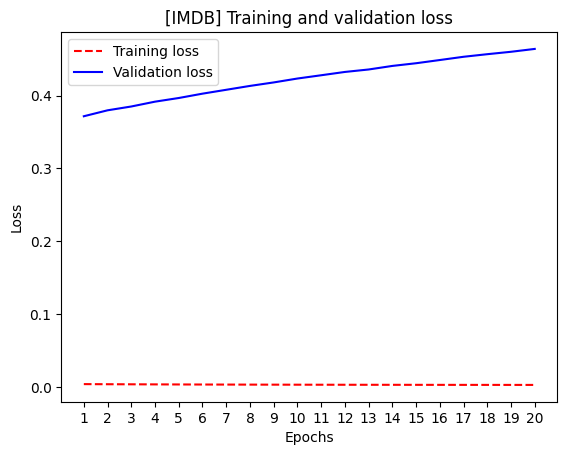

In [20]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

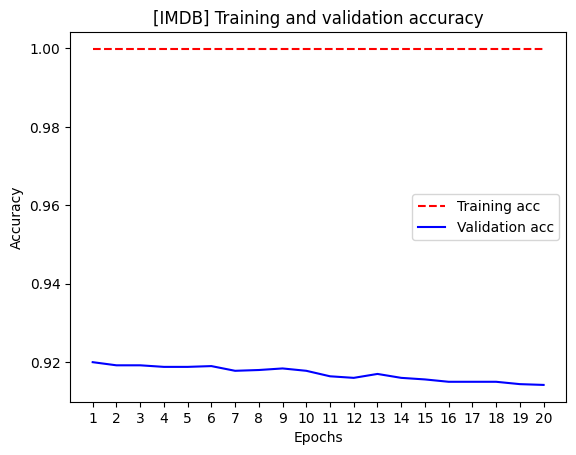

In [21]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [22]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
    shuffle=True,
)
#model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8010 - loss: 0.4909 - val_accuracy: 0.8778 - val_loss: 0.3318
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9142 - loss: 0.2493 - val_accuracy: 0.8926 - val_loss: 0.2746
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9419 - loss: 0.1756 - val_accuracy: 0.8896 - val_loss: 0.2830
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9552 - loss: 0.1370 - val_accuracy: 0.8902 - val_loss: 0.2928
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9673 - loss: 0.1096 - val_accuracy: 0.8828 - val_loss: 0.3184
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9709 - loss: 0.0959 - val_accuracy: 0.8844 - val_loss: 0.3482
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9797 - loss: 0.0749 - val_accuracy: 0.8762 - val_loss: 0.3698
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9868 - loss: 0.0590 - val_accuracy: 0.8722 - v

In [23]:
results

[0.7997782826423645, 0.8550799489021301]

#### Using a trained model to generate predictions on new data

In [24]:
predictions = model.predict(x_test, batch_size=64)# default batch size is 32

391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [25]:
len(predictions)

25000

#### Further experiments

In [26]:
model = keras.Sequential(
    [
        layers.Dense(6, activation="tanh"),
        layers.Dense(1, activation="tanh"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["accuracy"],
)
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
)
#model.fit(x_train, y_train, epochs=4, batch_size=512)
#results = model.evaluate(x_test, y_test)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7909 - loss: 0.1724 - val_accuracy: 0.8700 - val_loss: 0.1304
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9031 - loss: 0.1085 - val_accuracy: 0.8800 - val_loss: 0.1127
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9266 - loss: 0.0889 - val_accuracy: 0.8916 - val_loss: 0.1025
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9410 - loss: 0.0765 - val_accuracy: 0.8886 - val_loss: 0.0984
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9528 - loss: 0.0669 - val_accuracy: 0.8906 - val_loss: 0.0949
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9610 - loss: 0.0596 - val_accuracy: 0.8904 - val_loss: 0.0929
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9679 - loss: 0.0536 - val_accuracy: 0.8866 - val_loss: 0.0923
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9721 - loss: 0.0485 - val_accuracy: 0.8878 - v

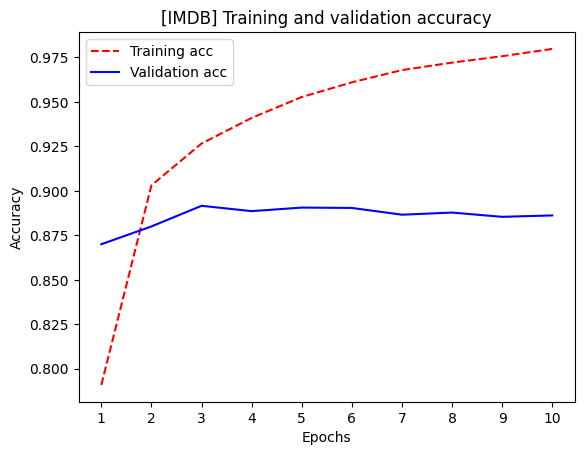

In [27]:
import matplotlib.pyplot as plt

history_dict = history.history
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
epochs = range(1, len(val_acc) + 1)
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [28]:
epochs

range(1, 11)

#### Wrapping up

### Classifying newswires: A multiclass classification example

#### The Reuters dataset

In [ ]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
len(train_data)

8982

In [ ]:
len(test_data)

2246

In [ ]:
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

In [ ]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_labels[10]

np.int64(3)

#### Preparing the data

In [ ]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

In [ ]:
my_list = [[0,1,2], [2,3], [5,2]]
results = np.zeros((len(my_list), 5+1))
for index, value in enumerate(my_list):
  #print(f"Index: {index}, Value: {value}")
  results[index][value] = 1.0
print(results)

[[1. 1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 1. 0. 0. 1.]]


In [ ]:
def one_hot_encode(labels, num_classes=46):
    results = np.zeros((len(labels), num_classes))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

y_train = one_hot_encode(train_labels)
y_test = one_hot_encode(test_labels)

In [ ]:
from keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

#### Building your model

In [ ]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)

In [ ]:
top_3_accuracy = keras.metrics.TopKCategoricalAccuracy(
    k=3, name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", top_3_accuracy],
)

#### Validating your approach

In [ ]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [ ]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.2417 - loss: 3.5595 - top_3_accuracy: 0.4550 - val_accuracy: 0.5690 - val_loss: 2.5532 - val_top_3_accuracy: 0.7120
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.5983 - loss: 2.1784 - top_3_accuracy: 0.7385 - val_accuracy: 0.6310 - val_loss: 1.6472 - val_top_3_accuracy: 0.7510
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.6750 - loss: 1.4669 - top_3_accuracy: 0.7828 - val_accuracy: 0.7140 - val_loss: 1.3024 - val_top_3_accuracy: 0.8120
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7591 - loss: 1.1000 - top_3_accuracy: 0.8460 - val_accuracy: 0.7560 - val_loss: 1.1298 - val_top_3_accuracy: 0.8450
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8251 - loss: 0.8235 - top_3_accuracy: 0.8994 - val_accuracy: 0.7750 - val_loss: 1.0310 - val_top_3_accuracy: 0.8810
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8699 - loss: 0.6396 - top_3_a

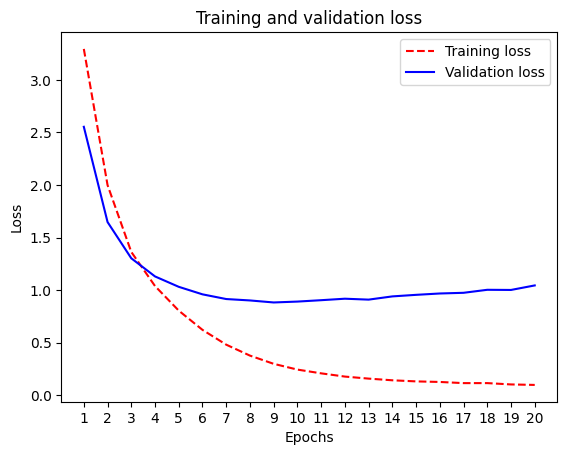

In [ ]:
import matplotlib.pyplot as plt
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

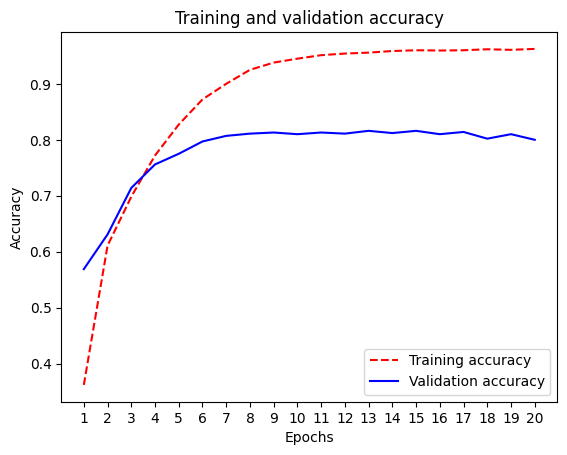

In [ ]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

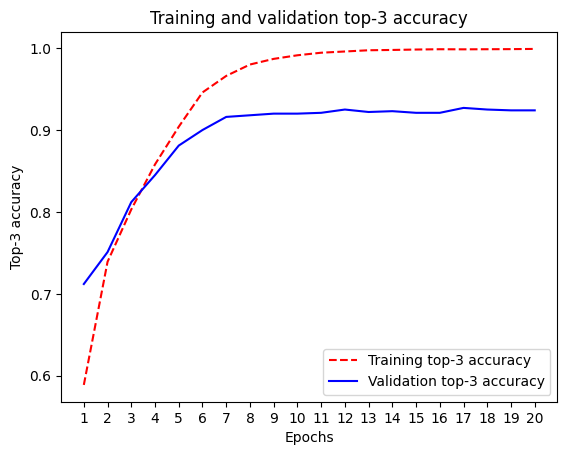

In [ ]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.3135 - loss: 3.4897
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5895 - loss: 2.0977
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6999 - loss: 1.3807
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7645 - loss: 1.0526
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8231 - loss: 0.8186
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8711 - loss: 0.6243
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9059 - loss: 0.4742
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9209 - loss: 0.3736
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.9367 - loss: 0.2906
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8122 - loss: 0.8960


In [ ]:
results

[0.9359790682792664, 0.8036509156227112]

In [ ]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()

np.float64(0.20169189670525378)

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
predictions[0].shape

(46,)

In [ ]:
np.sum(predictions[0])

np.float32(0.9999999)

In [ ]:
np.argmax(predictions[0])

np.int64(3)

#### A different way to handle the labels and the loss

In [ ]:
y_train = train_labels
y_test = test_labels

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.0374 - loss: 3.4881 - val_accuracy: 0.5110 - val_loss: 2.3312
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5349 - loss: 2.0086 - val_accuracy: 0.5680 - val_loss: 1.6264
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5983 - loss: 1.4837 - val_accuracy: 0.6390 - val_loss: 1.5082
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6751 - loss: 1.3070 - val_accuracy: 0.6580 - val_loss: 1.4566
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6829 - loss: 1.2156 - val_accuracy: 0.6500 - val_loss: 1.4273
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6896 - loss: 1.1142 - val_accuracy: 0.6520 - val_loss: 1.4163
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6935 - loss: 1.0516 - val_accuracy: 0.6500 - val_loss: 1.4089
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7110 - loss: 0.9961 - val_accuracy: 0.6440 - v

#### Further experiments

#### Wrapping up

### Predicting house prices: A regression example

#### The California Housing Price dataset

In [ ]:
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_data.shape

(480, 8)

In [ ]:
test_data.shape

(120, 8)

In [ ]:
int(train_targets.std())

101582

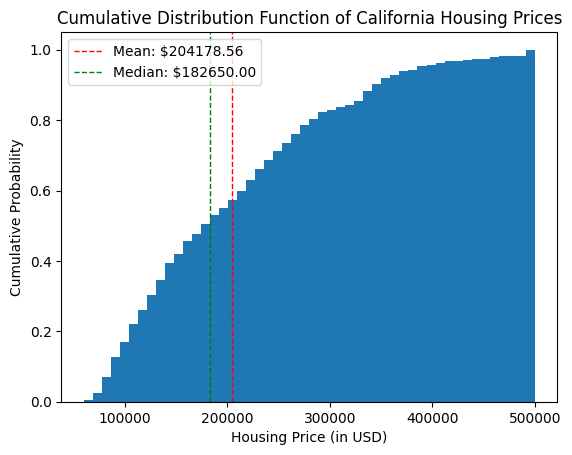

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(train_targets, bins=50, cumulative=True, density=True)
plt.xlabel("Housing Price (in USD)")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution Function of California Housing Prices")

# Calculate and plot mean and median
mean_price = np.mean(train_targets)
median_price = np.median(train_targets)

plt.axvline(mean_price, color='r', linestyle='dashed', linewidth=1, label=f'Mean: ${mean_price:.2f}')
plt.axvline(median_price, color='g', linestyle='dashed', linewidth=1, label=f'Median: ${median_price:.2f}')

plt.legend()
plt.show()

#### Preparing the data

In [ ]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std

In [ ]:
mean

array([-122.23098  ,   37.807056 ,   44.429165 , 1976.0708   ,
        421.8125   ,  994.6646   ,  397.75     ,    3.5265813],
      dtype=float32)

In [ ]:
y_train = train_targets / median_price
y_test = test_targets / median_price

#### Building your model

In [ ]:
def get_model():
    model = keras.Sequential(
        [
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(1),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model

#### Validating your approach using K-fold validation

In [ ]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [ ]:
[round(value, 3) for value in all_scores]

[0.163, 0.183, 0.134, 0.164]

In [ ]:
round(np.mean(all_scores), 3)

np.float64(0.161)

In [ ]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [ ]:
history.history.keys()
"""Keras provides a wide range of built-in metrics you can use, and yes, you can also define your own custom metrics!

Here are some common built-in metrics you can choose from:

Regression Metrics:
MeanSquaredError (or 'mse')
MeanAbsoluteError (or 'mae')
MeanAbsolutePercentageError (or 'mape')
MeanSquaredLogarithmicError (or 'msle')
RootMeanSquaredError (or 'rmse')
KLDivergence (or 'kld')
CosineSimilarity (or 'cosine_similarity')
Classification Metrics:
Accuracy (or 'accuracy')
BinaryAccuracy (or 'binary_accuracy')
CategoricalAccuracy (or 'categorical_accuracy')
TopKCategoricalAccuracy (or 'top_k_categorical_accuracy')
SparseCategoricalAccuracy (or 'sparse_categorical_accuracy')
Precision (or 'precision')
Recall (or 'recall')
F1Score (or 'f1_score')
AUC (or 'auc')
Other Metrics:
MeanIoU (Mean Intersection over Union, often used in image segmentation)
You can specify these metrics by their string names (like 'accuracy') or by using their class names from keras.metrics.

Defining a bespoke metric:

Yes, you can define a bespoke (custom) metric by creating a class that inherits from tf.keras.metrics.Metric """

"Keras provides a wide range of built-in metrics you can use, and yes, you can also define your own custom metrics!\n\nHere are some common built-in metrics you can choose from:\n\nRegression Metrics:\nMeanSquaredError (or 'mse')\nMeanAbsoluteError (or 'mae')\nMeanAbsolutePercentageError (or 'mape')\nMeanSquaredLogarithmicError (or 'msle')\nRootMeanSquaredError (or 'rmse')\nKLDivergence (or 'kld')\nCosineSimilarity (or 'cosine_similarity')\nClassification Metrics:\nAccuracy (or 'accuracy')\nBinaryAccuracy (or 'binary_accuracy')\nCategoricalAccuracy (or 'categorical_accuracy')\nTopKCategoricalAccuracy (or 'top_k_categorical_accuracy')\nSparseCategoricalAccuracy (or 'sparse_categorical_accuracy')\nPrecision (or 'precision')\nRecall (or 'recall')\nF1Score (or 'f1_score')\nAUC (or 'auc')\nOther Metrics:\nMeanIoU (Mean Intersection over Union, often used in image segmentation)\nYou can specify these metrics by their string names (like 'accuracy') or by using their class names from keras.met

In [ ]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

In [ ]:
len(all_mae_histories[0])

200

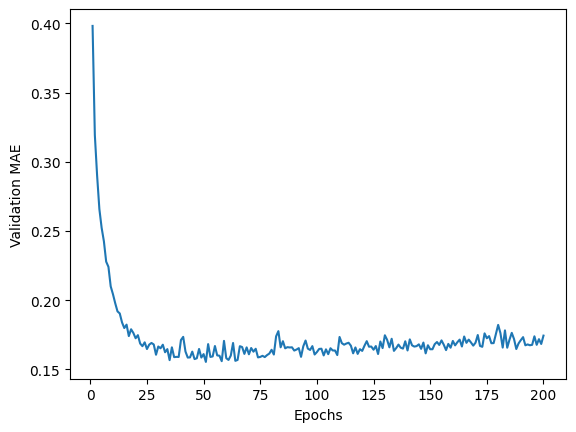

In [ ]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

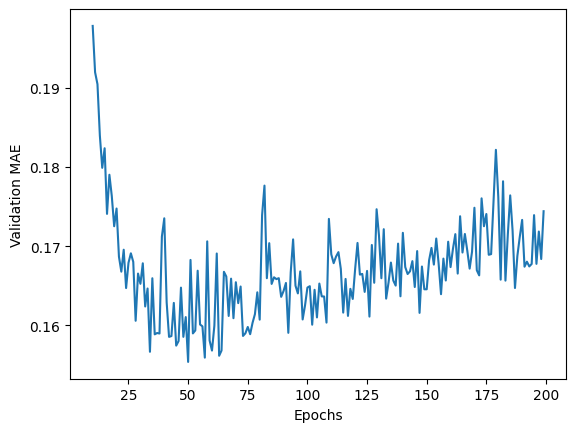

In [ ]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [ ]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0904 - mean_absolute_error: 0.1869 


In [ ]:
round(test_mean_absolute_error, 3)

0.178

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)
k = 6
for kk in range(k):
  pairr = (predictions[kk][0]*median_price, y_test[kk]*median_price)
  print(f'For district {kk}, the prediction is {pairr[0]:.2f} and the real value is {pairr[1]:.2f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
For district 0, the prediction is 256365.03 and the real value is 218800.00
For district 1, the prediction is 177237.56 and the real value is 218399.98
For district 2, the prediction is 142010.34 and the real value is 93800.00
For district 3, the prediction is 248785.22 and the real value is 173400.00
For district 4, the prediction is 233195.42 and the real value is 229700.00
For district 5, the prediction is 299094.59 and the real value is 371000.03


#### Wrapping up